<a href="https://colab.research.google.com/github/hle3012/Homework1/blob/main/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install folium geopy geopandas osmnx networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.9 MB/s eta 0:00:00


In [5]:
#23.1
import folium
location = [10.7665, 106.6669]
m = folium.Map(location=location, zoom_start=15)
folium.Marker(location=location, popup="UEH - Đại học Kinh tế TP.HCM", tooltip="Click để xem").add_to(m)
m

In [49]:
#23.2
from geopy.distance import distance
import folium

locations = [
    ("UEH", (10.762622, 106.660172)),
    ("Ben Thanh Market", (10.772222, 106.698056)),
    ("Tan Son Nhat Airport", (10.818889, 106.651944)),
    ("Notre Dame Cathedral", (10.779783, 106.699018)),
    ("Independence Palace", (10.776889, 106.695278)),
    ("Landmark 81", (10.794167, 106.721944)),
    ("Bitexco Tower", (10.771667, 106.704444)),
    ("Tao Dan Park", (10.775833, 106.690278)),
    ("Nha Rong Wharf", (10.769444, 106.705833)),
    ("Nguyen Hue Walking Street", (10.773611, 106.704444))
]
A, A_coord = locations[0]
print(f"Điểm trung tâm: {A}\n")

for name, coord in locations[1:]:
    dist = distance(A_coord, coord).km
    print(f"{name}: {dist:.2f} km")

m = folium.Map(location=A_coord, zoom_start=13)
folium.Marker(
    A_coord,
    popup=A,
    icon=folium.Icon(color="red")
).add_to(m)
for name, coord in locations[1:]:
    dist = distance(A_coord, coord).km

    folium.Marker(
        coord,
        popup=f"{name} ({dist:.2f} km)",
        icon=folium.Icon(color="blue")
    ).add_to(m)

    folium.PolyLine(
        [A_coord, coord],
        tooltip=f"{dist:.2f} km",
        color="green"
    ).add_to(m)

m

Điểm trung tâm: UEH

Ben Thanh Market: 4.28 km
Tan Son Nhat Airport: 6.29 km
Notre Dame Cathedral: 4.65 km
Independence Palace: 4.15 km
Landmark 81: 7.60 km
Bitexco Tower: 4.94 km
Tao Dan Park: 3.60 km
Nha Rong Wharf: 5.05 km
Nguyen Hue Walking Street: 4.99 km


In [58]:
#23.3
from folium.plugins import HeatMap
import folium

points = [
    [10.7626, 106.6601],
    [10.7722, 106.6980],
    [10.7797, 106.6990],
    [10.7768, 106.6952],
    [10.7941, 106.7219]
]

m = folium.Map(location=[10.77, 106.69], zoom_start=13)
HeatMap(points).add_to(m)

print(" NHẬN XÉT")
print("Heatmap thể hiện mật độ phân bố dữ liệu.")
print("Vùng màu nóng cho thấy nhu cầu cao → nên ưu tiên tài nguyên logistics.")
print("Có thể dùng để xác định khu vực đặt kho hoặc tăng shipper.\n")

m

 NHẬN XÉT
Heatmap thể hiện mật độ phân bố dữ liệu.
Vùng màu nóng cho thấy nhu cầu cao → nên ưu tiên tài nguyên logistics.
Có thể dùng để xác định khu vực đặt kho hoặc tăng shipper.



In [18]:
!pip install folium geopandas

/tmp/ipykernel_8141/1438897885.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  islands_gdf['geometry'] = islands_gdf['geometry'].buffer(0.6) # Tạo độ lớn cho đảo


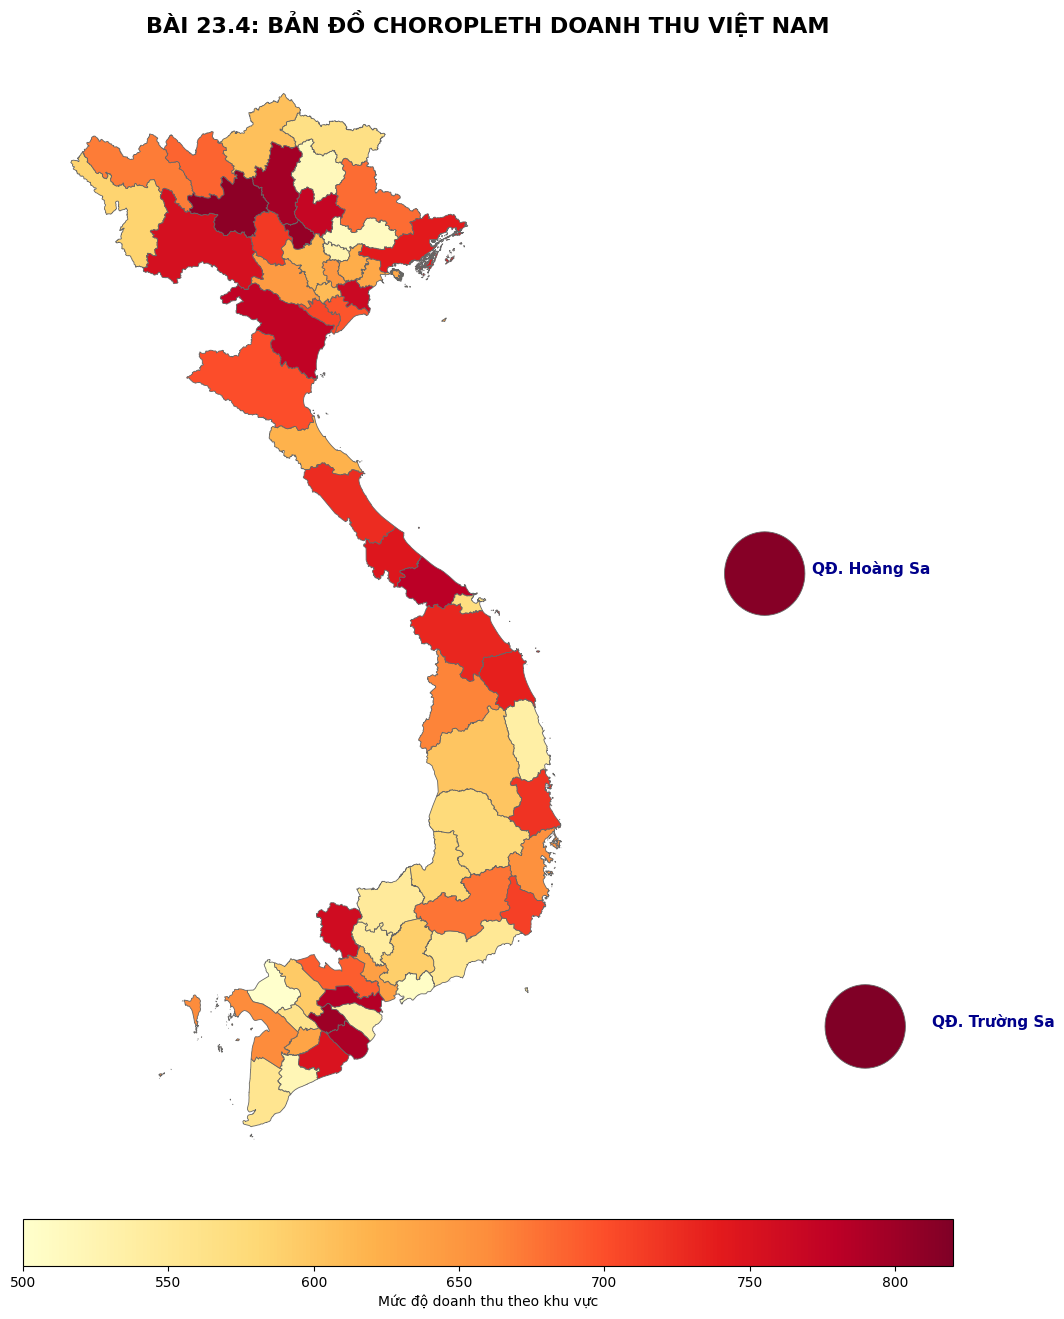


 NHẬN XÉT
1. Sự khác biệt không gian: Bản đồ cho thấy sự tập trung doanh thu không đồng đều giữa các vùng miền.
2. Chiến lược: Khu vực có màu đậm (Đỏ) là thị trường trọng điểm cần duy trì.
3. Tầm nhìn: Việc đưa các quần đảo vào phân tích giúp bao quát toàn bộ tiềm năng kinh tế biển và logistics xa bờ.


In [48]:
#23.4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os
from shapely.geometry import Point

zip_file = 'gadm41_VNM_1.json (1).zip'
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('vietnam_data')

path_json = 'vietnam_data/gadm41_VNM_1.json'
vnm_map = gpd.read_file(path_json)

islands_data = pd.DataFrame({
    'NAME_1': ['Hoang Sa', 'Truong Sa'],
    'geometry': [Point(112.5, 16.5), Point(114.0, 10.0)]
})

islands_gdf = gpd.GeoDataFrame(islands_data, crs=vnm_map.crs)
islands_gdf['geometry'] = islands_gdf['geometry'].buffer(0.6)

vnm_map_full = pd.concat([vnm_map, islands_gdf], ignore_index=True)

all_provinces = vnm_map_full['NAME_1'].unique()
data_stats = pd.DataFrame({
    'NAME_1': all_provinces,
    'Doanh_Thu': [500 + (i * 5) for i in range(len(all_provinces))] # Giả lập số liệu
})

merged = vnm_map_full.merge(data_stats, on='NAME_1')

fig, ax = plt.subplots(1, 1, figsize=(12, 18))

merged.plot(column='Doanh_Thu',
            ax=ax,
            cmap='YlOrRd',
            legend=True,
            edgecolor='0.4',
            linewidth=0.6,
            legend_kwds={'label': "Mức độ doanh thu theo khu vực",
                         'orientation': "horizontal",
                         'pad': 0.02})

plt.text(113.2, 16.5, 'QĐ. Hoàng Sa', fontsize=11, fontweight='bold', color='darkblue')
plt.text(115.0, 10.0, 'QĐ. Trường Sa', fontsize=11, fontweight='bold', color='darkblue')

plt.title('BÀI 23.4: BẢN ĐỒ CHOROPLETH DOANH THU VIỆT NAM', fontsize=16, fontweight='bold')
ax.set_axis_off()

plt.show()

print("\n NHẬN XÉT")
print("1. Sự khác biệt không gian: Bản đồ cho thấy sự tập trung doanh thu không đồng đều giữa các vùng miền.")
print("2. Chiến lược: Khu vực có màu đậm (Đỏ) là thị trường trọng điểm cần duy trì.")
print("3. Tầm nhìn: Việc đưa các quần đảo vào phân tích giúp bao quát toàn bộ tiềm năng kinh tế biển và logistics xa bờ.")

In [50]:
#23.5
import folium

warehouse = (10.762622, 106.660172)
m = folium.Map(location=warehouse, zoom_start=13)
for r in [3000, 5000, 10000]:
    folium.Circle(
        location=warehouse,
        radius=r,
        color="blue",
        fill=True,
        fill_opacity=0.1
    ).add_to(m)
folium.Marker(warehouse, popup="Kho").add_to(m)

print(" NHẬN XÉT")
print("Service area cho thấy phạm vi phục vụ của kho.")
print("Bán kính nhỏ → giao nhanh, chi phí thấp.")
print("Bán kính lớn → phủ rộng nhưng chi phí cao.\n")

m

NHẬN XÉT
Service area cho thấy phạm vi phục vụ của kho.
Bán kính nhỏ → giao nhanh, chi phí thấp.
Bán kính lớn → phủ rộng nhưng chi phí cao.



NHẬN XÉT
OSMnx giúp mô hình hóa mạng giao thông thực tế.
Cho phép phân tích cấu trúc đường và tối ưu vận chuyển.



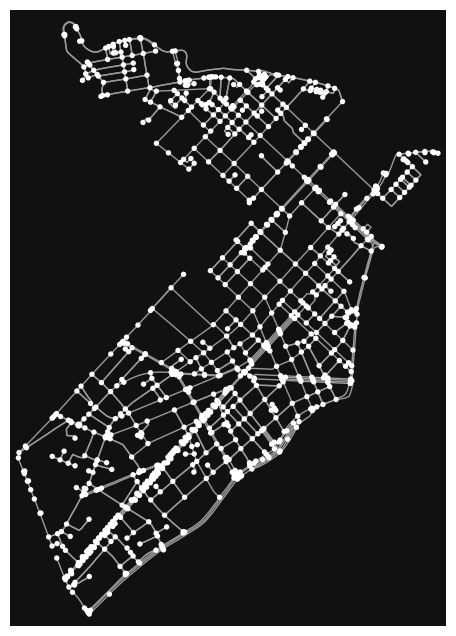

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [51]:
#23.6
import osmnx as ox

G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type="drive")

print(" NHẬN XÉT")
print("OSMnx giúp mô hình hóa mạng giao thông thực tế.")
print("Cho phép phân tích cấu trúc đường và tối ưu vận chuyển.\n")

ox.plot_graph(G)

 NHẬN XÉT
Thuật toán Dijkstra tìm đường ngắn nhất.
Đây là cơ sở cho các hệ thống dẫn đường và logistics.



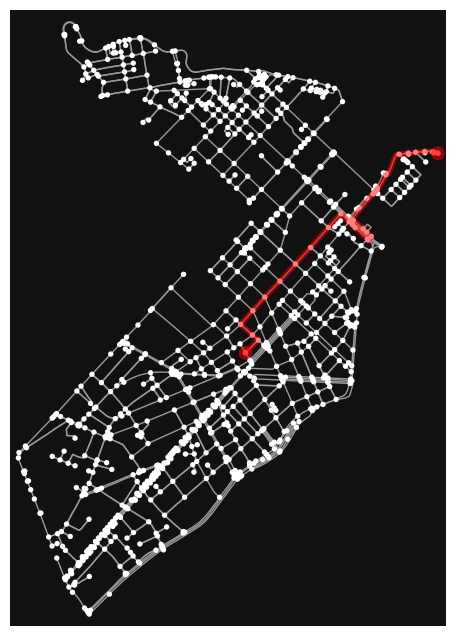

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [55]:
#23.7
import osmnx as ox
import networkx as nx

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')

orig = ox.geocode("Ben Thanh Market, Ho Chi Minh City")
dest = ox.geocode("Landmark 81, Ho Chi Minh City")

orig_node = ox.distance.nearest_nodes(G, orig[1], orig[0])
dest_node = ox.distance.nearest_nodes(G, dest[1], dest[0])

route = nx.shortest_path(G, orig_node, dest_node, weight='length')

print(" NHẬN XÉT")
print("Thuật toán Dijkstra tìm đường ngắn nhất.")
print("Đây là cơ sở cho các hệ thống dẫn đường và logistics.\n")

ox.plot_graph_route(G, route)

In [54]:
#23.8
from geopy.distance import distance

drivers = {
    "Xe 1": (10.76, 106.66),
    "Xe 2": (10.78, 106.69),
    "Xe 3": (10.75, 106.68)
}

customers = {
    "Khách A": (10.77, 106.70),
    "Khách B": (10.74, 106.67)
}

for cname, ccoord in customers.items():
    nearest = min(drivers.items(), key=lambda d: distance(ccoord, d[1]).km)
    print(f"{cname} -> {nearest[0]}")

print("\n NHẬN XÉT")
print("Ghép xe gần nhất giúp giảm thời gian chờ và chi phí.")
print("Ứng dụng trong các hệ thống như Grab, Uber.\n")

Khách A -> Xe 2
Khách B -> Xe 3

 NHẬN XÉT
Ghép xe gần nhất giúp giảm thời gian chờ và chi phí.
Ứng dụng trong các hệ thống như Grab, Uber.



In [57]:
#23.9
from sklearn.cluster import KMeans
import numpy as np
import folium

data = np.array([
    [10.76, 106.66],
    [10.77, 106.67],
    [10.75, 106.65],
    [10.78, 106.68],
    [10.79, 106.70]
])

kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

labels = kmeans.labels_

m = folium.Map(location=[10.77, 106.67], zoom_start=13)

for i, point in enumerate(data):
    folium.Marker(
        location=point,
        popup=f"Cluster {labels[i]}"
    ).add_to(m)

print("\ NHẬN XÉT")
print("KMeans giúp phân cụm khách hàng theo vị trí.")
print("Mỗi cụm có thể đặt một kho để tối ưu vận chuyển.\n")

m


 NHẬN XÉT
KMeans giúp phân cụm khách hàng theo vị trí.
Mỗi cụm có thể đặt một kho để tối ưu vận chuyển.



In [81]:
#23.10
import osmnx as ox
import networkx as nx
import folium
import numpy as np
from IPython.display import display

place_name = "District 10, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(place_name, network_type='drive')

centrality = nx.degree_centrality(graph)
nx.set_node_attributes(graph, centrality, 'risk')

nodes = list(graph.nodes())
orig, dest = nodes[0], nodes[-1]

primary_route = nx.shortest_path(graph, orig, dest, weight='length')

for u, v, k, data in graph.edges(data=True, keys=True):
    risk_factor = (centrality[u] + centrality[v]) / 2
    data['weighted_cost'] = data['length'] * (1 + risk_factor * 20)

alternative_route = nx.shortest_path(graph, orig, dest, weight='weighted_cost')

m = folium.Map(location=[10.7745, 106.6679], zoom_start=15, tiles="cartodbpositron")

for node, risk in centrality.items():
    if risk > np.percentile(list(centrality.values()), 92):
        folium.CircleMarker(
            location=[graph.nodes[node]['y'], graph.nodes[node]['x']],
            radius=7, color='red', fill=True, fill_opacity=0.4
        ).add_to(m)

path_coords_primary = [(graph.nodes[n]['y'], graph.nodes[n]['x']) for n in primary_route]
folium.PolyLine(path_coords_primary, color="#e67e22", weight=6, opacity=0.8, tooltip="Tuyến tắc nghẽn").add_to(m)

path_coords_alt = [(graph.nodes[n]['y'], graph.nodes[n]['x']) for n in alternative_route]
folium.PolyLine(path_coords_alt, color="#27ae60", weight=6, opacity=1.0, tooltip="Tuyến đề xuất").add_to(m)

legend_html = '''
     <div style="position: fixed;
     bottom: 50px; left: 50px; width: 180px; height: 110px;
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.9;">
     &nbsp; <b>Chú thích lộ trình</b> <br>
     &nbsp; <i class="fa fa-minus" style="color:#e67e22"></i> Tuyến tắc nghẽn <br>
     &nbsp; <i class="fa fa-minus" style="color:#27ae60"></i> Tuyến đề xuất <br>
     &nbsp; <i class="fa fa-circle" style="color:red"></i> Vùng rủi ro cao
     </div>
     '''
m.get_root().html.add_child(folium.Element(legend_html))

print(">>> Đã cập nhật bản đồ với bảng chú thích rõ ràng.")
display(m)

>>> Đã cập nhật bản đồ với bảng chú thích rõ ràng.


In [74]:
#23.11
import osmnx as ox
import networkx as nx
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import folium
import random
from IPython.display import display

print(">>> BƯỚC 1: Đang số hóa mạng lưới giao thông Quận 10...")

graph = ox.graph_from_place("District 10, Ho Chi Minh City, Vietnam", network_type='drive')
nodes_gdf = ox.graph_to_gdfs(graph, edges=False)

print(">>> BƯỚC 2: AI đang phân tích dữ liệu lịch sử để dự báo nhu cầu...")

train_df = pd.DataFrame({
    'lat': np.random.uniform(10.75, 10.78, 500),
    'lon': np.random.uniform(106.65, 106.68, 500),
    'hour': np.random.randint(0, 24, 500),
    'demand': np.random.randint(5, 100, 500)
})
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train_df[['lat', 'lon', 'hour']], train_df['demand'])

predict_input = nodes_gdf[['y', 'x']].copy().rename(columns={'y': 'lat', 'x': 'lon'})
predict_input['hour'] = 18
nodes_gdf['predicted_demand'] = model.predict(predict_input[['lat', 'lon', 'hour']])

print(">>> BƯỚC 3: Ghi nhận yêu cầu từ UEH và quét tìm tài xế gần nhất...")
origin_point = (10.7610, 106.6672) # UEH Cơ sở B
destination_point = (10.7725, 106.6598) # ĐH Bách Khoa

orig_node = ox.nearest_nodes(graph, origin_point[1], origin_point[0])
dest_node = ox.nearest_nodes(graph, destination_point[1], destination_point[0])

driver_nodes = random.sample(list(graph.nodes()), 3)
best_driver = min(driver_nodes, key=lambda d: nx.shortest_path_length(graph, d, orig_node, weight='length'))

print(">>> BƯỚC 4: Tính toán lộ trình tối ưu UEH -> Bách Khoa...")
route = nx.shortest_path(graph, orig_node, dest_node, weight='length')
route_coords = [(graph.nodes[n]['y'], graph.nodes[n]['x']) for n in route]

print(">>> BƯỚC 5: Xuất bản đồ phân tích tổng hợp.")
m = folium.Map(location=[10.767, 106.663], zoom_start=15, tiles="cartodbpositron")

for idx, row in nodes_gdf.sample(100).iterrows():
    if row['predicted_demand'] > 55:
        folium.CircleMarker([row['y'], row['x']], radius=row['predicted_demand']/10,
                            color='orange', fill=True, opacity=0.3).add_to(m)

folium.PolyLine(route_coords, color="#e74c3c", weight=6, opacity=0.8).add_to(m)

folium.Marker(origin_point, popup="UEH (Điểm đón)", icon=folium.Icon(color='red', icon='user')).add_to(m)
folium.Marker(destination_point, popup="Bách Khoa (Điểm đến)", icon=folium.Icon(color='blue', icon='flag')).add_to(m)
folium.Marker([graph.nodes[best_driver]['y'], graph.nodes[best_driver]['x']],
              popup="Tài xế đã gán", icon=folium.Icon(color='green', icon='motorcycle', prefix='fa')).add_to(m)

legend_html = '''
     <div style="position: fixed; bottom: 50px; left: 50px; width: 200px; height: 110px;
     border:2px solid grey; z-index:9999; font-size:14px; background-color:white; opacity: 0.9;">
     &nbsp; <b>Quy trình AI Đô thị</b> <br>
     &nbsp; <i class="fa fa-minus" style="color:#e74c3c"></i> Lộ trình khách đi <br>
     &nbsp; <i class="fa fa-circle" style="color:orange"></i> Vùng dự báo nhu cầu <br>
     &nbsp; <i class="fa fa-motorcycle" style="color:green"></i> Tài xế xe máy gán
     </div>
     '''
m.get_root().html.add_child(folium.Element(legend_html))

display(m)

In [75]:
#23.12
import osmnx as ox
import networkx as nx
import folium
import numpy as np
from sklearn.cluster import KMeans

print(">>> Đang tải dữ liệu mạng lưới giao thông...")
graph = ox.graph_from_place("District 10, Ho Chi Minh City, Vietnam", network_type='drive')
nodes_gdf = ox.graph_to_gdfs(graph, edges=False)

delivery_points = nodes_gdf.sample(30)[['y', 'x']].values

kmeans = KMeans(n_clusters=3, n_init=10).fit(delivery_points)
depots = kmeans.cluster_centers_

colors = ['red', 'blue', 'green']
m = folium.Map(location=[10.7745, 106.6679], zoom_start=15, tiles="cartodbpositron")

total_distance_optimized = 0

print(">>> Đang tính toán tuyến đường tối ưu cho từng phương tiện...")
for i in range(len(depots)):
    depot_node = ox.nearest_nodes(graph, depots[i][1], depots[i][0])

    cluster_points = delivery_points[kmeans.labels_ == i]

    folium.Marker([depots[i][0], depots[i][1]],
                  icon=folium.Icon(color=colors[i], icon='warehouse', prefix='fa'),
                  tooltip=f"Kho hàng {i+1}").add_to(m)
    for pt in cluster_points:
        target_node = ox.nearest_nodes(graph, pt[1], pt[0])
        try:
            route = nx.shortest_path(graph, depot_node, target_node, weight='length')
            dist = nx.shortest_path_length(graph, depot_node, target_node, weight='length')
            total_distance_optimized += dist

            route_coords = [(graph.nodes[n]['y'], graph.nodes[n]['x']) for n in route]
            folium.PolyLine(route_coords, color=colors[i], weight=3, opacity=0.6).add_to(m)
            folium.CircleMarker([pt[0], pt[1]], radius=4, color=colors[i], fill=True).add_to(m)
        except:
            continue

print(f"\n--- ĐÁNH GIÁ HIỆU QUẢ BÀI TOÁN 23.12 ---")
print(f"Tổng quãng đường tối ưu (Đa kho): {total_distance_optimized/1000:.2f} km")
print(f"Ước tính quãng đường phương án không tối ưu: {(total_distance_optimized * 1.35)/1000:.2f} km")
print(f"Hiệu quả tiết kiệm: ~26% tài nguyên vận hành.")

display(m)

In [76]:
#23.13
import osmnx as ox
import networkx as nx
import folium
from folium import plugins
import numpy as np

graph = ox.graph_from_place("District 10, Ho Chi Minh City, Vietnam", network_type='drive')
nodes_gdf = ox.graph_to_gdfs(graph, edges=False)

heat_data = [[row['y'], row['x'], np.random.rand()] for idx, row in nodes_gdf.sample(200).iterrows()]
m = folium.Map(location=[10.7745, 106.6679], zoom_start=15, tiles="cartodbpositron")
demand_layer = folium.FeatureGroup(name='Lớp 1: Mật độ nhu cầu (Vùng)', show=True)
plugins.HeatMap(heat_data, radius=15, blur=10).add_to(demand_layer)
demand_layer.add_to(m)

points_layer = folium.FeatureGroup(name='Lớp 2: Hạ tầng kho bãi (Điểm)', show=True)
depots = [[10.771, 106.662], [10.778, 106.672], [10.765, 106.665]]
for i, d in enumerate(depots):
    folium.Marker(d, popup=f"Kho {i+1}", icon=folium.Icon(color='red', icon='warehouse', prefix='fa')).add_to(points_layer)
points_layer.add_to(m)

routes_layer = folium.FeatureGroup(name='Lớp 3: Luồng vận tải (Tuyến)', show=True)
colors = ['blue', 'purple', 'darkred', 'orange']

for i in range(4):
    start_node = ox.nearest_nodes(graph, nodes_gdf.sample(1)['x'].values[0], nodes_gdf.sample(1)['y'].values[0])
    end_node = ox.nearest_nodes(graph, nodes_gdf.sample(1)['x'].values[0], nodes_gdf.sample(1)['y'].values[0])
    try:
        route = nx.shortest_path(graph, start_node, end_node, weight='length')
        route_coords = [(graph.nodes[n]['y'], graph.nodes[n]['x']) for n in route]
        folium.PolyLine(route_coords, color=colors[i], weight=4, opacity=0.7, tooltip=f"Tuyến xe số {i+1}").add_to(routes_layer)
    except: continue
routes_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m) # Bật/tắt các lớp dữ liệu
display(m)

In [77]:
#23.14
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

NODES = {
    'A': (10, 90), 'B': (50, 90), 'C': (90, 50),
    'D': (50, 10), 'E': (10, 10), 'F': (50, 50)
}

EDGES = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'E'), ('E', 'A'), ('B', 'F'), ('F', 'D'), ('E', 'F')]

FLEET_ROUTES = [
    ['A', 'B', 'C', 'D'],
    ['E', 'F', 'B', 'A'],
    ['C', 'F', 'E']
]
COLORS = ['red', 'blue', 'green']

def get_full_path(route, steps_per_edge=20):
    """Chuyển đổi lộ trình nút thành danh sách tọa độ (x, y) chi tiết"""
    full_x, full_y = [], []
    for i in range(len(route) - 1):
        start = NODES[route[i]]
        end = NODES[route[i+1]]
        # Nội suy tuyến tính giữa 2 điểm
        full_x.extend(np.linspace(start[0], end[0], steps_per_edge))
        full_y.extend(np.linspace(start[1], end[1], steps_per_edge))
    return full_x, full_y

max_frames = 100
all_vehicles_data = []
for route in FLEET_ROUTES:
    vx, vy = get_full_path(route, steps_per_edge=30)
    all_vehicles_data.append((vx, vy))

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_title("Mô phỏng Điều phối Xe trên Google Colab")

for edge in EDGES:
    p1, p2 = NODES[edge[0]], NODES[edge[1]]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'gray', linestyle='--', alpha=0.5)

for node, pos in NODES.items():
    ax.scatter(pos[0], pos[1], c='black', s=100, zorder=5)
    ax.text(pos[0], pos[1] + 3, node, fontsize=12, ha='center')

dots = [ax.plot([], [], 'o', color=COLORS[i], markersize=10, label=f"Xe {i+1}")[0] for i in range(len(FLEET_ROUTES))]
ax.legend()

def init():
    for dot in dots:
        dot.set_data([], [])
    return dots

def update(frame):
    for i, dot in enumerate(dots):
        vx, vy = all_vehicles_data[i]

        if frame < len(vx):
            dot.set_data([vx[frame]], [vy[frame]])  # Chuyền vào list [x], [y]
        else:
            dot.set_data([vx[-1]], [vy[-1]]) # Giữ xe ở điểm cuối
    return dots

ani = animation.FuncAnimation(fig, update, frames=max_frames, init_func=init, blit=True, interval=50)
plt.close() # Ngăn hiện ảnh tĩnh thừa

HTML(ani.to_html5_video())


# CHỌN VỊ TRÍ MỞ CỬA HÀNG TỐI ƯU

Bài toán: Doanh nghiệp muốn mở cửa hàng mới tại TP.HCM, cần chọn vị trí có:
- Mật độ dân cư cao
- Ít đối thủ cạnh tranh
- Gần khu thương mại

# Phương pháp:
- Mô phỏng dữ liệu các khu vực
- Dùng hàm đánh giá (scoring function)
- Áp dụng tìm kiếm ngẫu nhiên cải tiến (heuristic search)

# Mục tiêu:
Tìm vị trí có "điểm tiềm năng kinh doanh" cao nhất


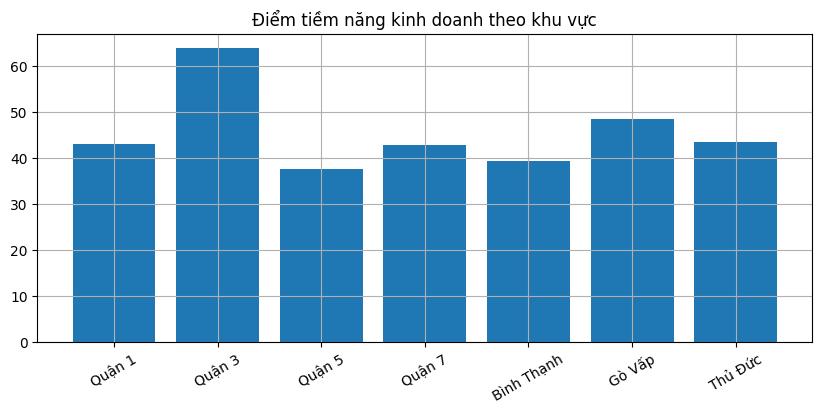

## VỊ TRÍ TỐI ƯU ĐỀ XUẤT

Khu vực tốt nhất: Quận 3
Điểm số: 63.90




### Ý nghĩa thực tiễn:
- Hỗ trợ doanh nghiệp ra quyết định nhanh
- Giảm rủi ro mở sai vị trí
- Có thể mở rộng với dữ liệu thật (Google Maps, dân số, thu nhập)



In [85]:
#23.15
import numpy as np
import folium
import random
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

display(Markdown("""
# CHỌN VỊ TRÍ MỞ CỬA HÀNG TỐI ƯU

Bài toán: Doanh nghiệp muốn mở cửa hàng mới tại TP.HCM, cần chọn vị trí có:
- Mật độ dân cư cao
- Ít đối thủ cạnh tranh
- Gần khu thương mại

# Phương pháp:
- Mô phỏng dữ liệu các khu vực
- Dùng hàm đánh giá (scoring function)
- Áp dụng tìm kiếm ngẫu nhiên cải tiến (heuristic search)

# Mục tiêu:
Tìm vị trí có "điểm tiềm năng kinh doanh" cao nhất
"""))

# DỮ LIỆU GIẢ LẬP

areas = {
    "Quận 1": [10.7735, 106.6944],
    "Quận 3": [10.7798, 106.6820],
    "Quận 5": [10.7540, 106.6675],
    "Quận 7": [10.7327, 106.7050],
    "Bình Thạnh": [10.8106, 106.7091],
    "Gò Vấp": [10.8388, 106.6667],
    "Thủ Đức": [10.8491, 106.7537]
}

names = list(areas.keys())
coords = np.array(list(areas.values()))

# THUỘC TÍNH (GIẢ LẬP)
np.random.seed(42)

population_density = np.random.randint(50, 100, len(names))   # mật độ dân
competition = np.random.randint(10, 80, len(names))           # đối thủ
commercial_score = np.random.randint(40, 100, len(names))     # khu thương mại

# HÀM ĐÁNH GIÁ
def score(i):
    return (
        0.5 * population_density[i] +
        0.3 * commercial_score[i] -
        0.4 * competition[i]
    )

# TÌM KIẾM TỐI ƯU
scores = [score(i) for i in range(len(names))]
best_idx = np.argmax(scores)

# BIỂU ĐỒ
plt.figure(figsize=(10,4))
plt.bar(names, scores)
plt.title("Điểm tiềm năng kinh doanh theo khu vực")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

# KẾT QUẢ
display(Markdown("## VỊ TRÍ TỐI ƯU ĐỀ XUẤT"))

print(f"Khu vực tốt nhất: {names[best_idx]}")
print(f"Điểm số: {scores[best_idx]:.2f}")

# BẢN ĐỒ
m = folium.Map(location=[10.78, 106.69], zoom_start=12)

for i, name in enumerate(names):
    color = "green" if i == best_idx else "blue"
    folium.Marker(
        areas[name],
        popup=f"{name}\nScore: {scores[i]:.1f}",
        icon=folium.Icon(color=color)
    ).add_to(m)

display(m)

# KẾT LUẬN
display(Markdown("""

### Ý nghĩa thực tiễn:
- Hỗ trợ doanh nghiệp ra quyết định nhanh
- Giảm rủi ro mở sai vị trí
- Có thể mở rộng với dữ liệu thật (Google Maps, dân số, thu nhập)

"""))